#  GenAI-101 - Introduction

<!-- > **"A compelling quote or key idea that frames the lesson."**
> — Ismail Hamdaoui / Paper -->

# Preface

It is needless to remind that all AI-algorithms, are backboned, motivated or emerged through a mathematical explanation — most commonly in some 
combination of calculus, linear algebra, and probability theory.

Take least squares as a familiar example: the algorithm solves an 
optimization problem, minimizing the sum of squared residuals — the 
distances between data points and a candidate line — to find the best 
linear approximation. The objective is clear, the solution is closed-form, 
and the output is always deterministic: one line.

But how is GenAI formulated mathematically ?

---

# I. Intuition

To solve What Does a Generative Model Need to Do? Let's try to build the intuition first through an example, Suppose we want a model that generates images of animals.
For such a model to be useful, it must satisfy at least two requirements:

1. **Diversity** — it must be capable of generating many different 
   categories: dogs, cats, horses, and so on.
2. **Expressiveness** — when asked for a cat, it should 
   produce a different cat each time: different poses, colors, backgrounds.

These two requirements immediately rule out deterministic functions.
A deterministic function maps each input to exactly one output — running it 
twice with the same input, get the same result, which doens't satisfy the diversity sought. It has no mechanism for 
variability. 

What we need is a mathematical object that natively represents 
**uncertainty and variability**. That object is a **random variable**.

<img src="docs/intro/func.png" width="700">

# II. Random Variables & Probability Distributions

A random variable $X$ is not simply "a different kind of function." 
Formally, it is a measurable function defined on a probability space — 
but what makes it powerful is that it carries a **probability distribution** 
$p(X)$ that governs how likely each outcome is.

Once we have a distribution, we can **sample** from it: draw a value 
according to its probabilities, get a different result each time, and 
yet have every result be consistent with the same underlying structure.

A Gaussian distribution, for instance, always produces numbers 
concentrated around its mean, with the spread controlled by its variance. 
Run it a thousand times — no two outputs are identical, yet all of them 
are statistically coherent. *run the below cell to multiple times to experience the sampling process from random variables*


In [17]:
import numpy as np

# ----------------------------
# 1. Gaussian sampling
# ----------------------------
mean = 0
std = 1

gaussian_samples = np.random.normal(mean, std)

print("Gaussian samples:")
print(gaussian_samples)


# ----------------------------
# 2. Uniform categorical (1 to 12)
# ----------------------------
categorical_samples = np.random.randint(1, 13)

print("\nCategorical samples (1 to 12):")
print(categorical_samples)

Gaussian samples:
0.40542814849727127

Categorical samples (1 to 12):
7





# III. Problem Formulation

A generative model's job is to **approximate an unknown data distribution**.

More precisely: we observe samples (images, text, audio) drawn from some 
true distribution $p_{data}$ that we cannot access directly. We want to 
learn a parametric distribution $p_\theta$ — controlled by parameters 
$\theta$ — such that $p_\theta \approx p_{data}$. Once we have that, 
we can sample from $p_\theta$ to generate new, realistic data.

<!-- Returning to our image example: generating 32×32 images means modeling 
a joint probability distribution over $\mathbb{R}^{32 \times 32}$ — 
a space of 1,024 dimensions. The challenge is not just the dimensionality 
itself, but the fact that **realistic images occupy an extremely small 
region of that space**. A random vector in $\mathbb{R}^{1024}$ looks 
like noise. A real dog image obeys thousands of implicit structural 
constraints — pixel continuity, object shapes, lighting coherence — and 
the distribution must encode all of them.

This is what makes generative modeling hard.
 -->


> 💡 **Insight:** 
> - *Under this formulation, clusters are captured through the modes of a
>   distribution. The more modes, the broader the coverage across categories
>   (types of animals in our example) — but the more complex the distribution
>   becomes to approximate.*
>
> - *The photo below shows how different modes are each responsible for
>   capturing a cluster of similar samples (this is a simplification —
>   no guarantee of what is actually happening under the hood).*
>
> <img src="docs/intro/zorse.png" width="700">
>
> - *Finally, this mathematical formulation reveals another interesting
>   property: **interpolation** between clusters. Once the distribution is
>   approximated, and if the model architecture permits it, one can interpolate
>   between real clusters to form entirely new entities — never seen during
>   training — whether realistic (like the Zorse, a zebra-horse hybrid) or
>   purely fantastical.*


# IV. Distribution Estimation — A Grounded Example

Before tackling image generation, let's practise with a simpler 
case: a population of 2D points.

We observe a finite set of points in the plane. We don't know the 
distribution that generated them — but we want to learn it well enough 
to generate new points that are statistically indistinguishable from the 
originals.

This is **density estimation**, and it is the core problem every 
generative model solves.

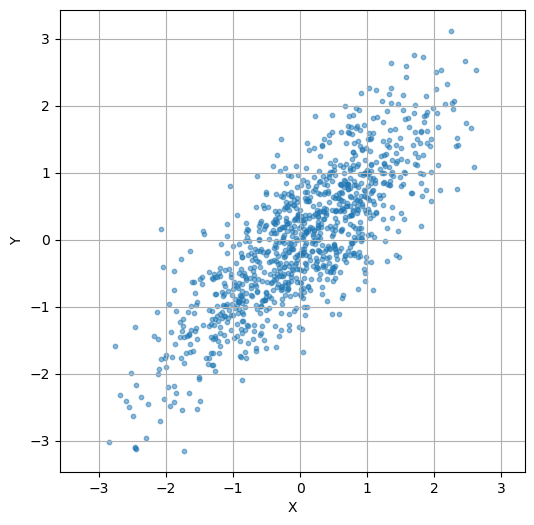

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Mean
mean = [0, 0]

# Standard deviations
sigma_x = 1
sigma_y = 1

# Correlation coefficient
rho = 0.8

# Correlation matrix
corr_matrix = np.array([
    [1, rho],
    [rho, 1]
])

# Convert to covariance matrix
std_matrix = np.array([
    [sigma_x, 0],
    [0, sigma_y]
])

cov_matrix = std_matrix @ corr_matrix @ std_matrix

# Generate points
n = 1000
data = np.random.multivariate_normal(mean, cov_matrix, n)
x, y = data[:, 0], data[:, 1]

# Plot (same clean style as before)
plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.5, s=10)

plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)

plt.show()

Looking at the graph, we can make a few key observations:

- The distribution lives in 2D space $\mathbb{R}^{2}$, so we need a 
  probability distribution over that space.
- The points are scattered symmetrically around a central point — the mean —
  meaning skewness (third moment) $\approx 0$. This makes a **Gaussian 
  assumption** valid here.
- We are now left with estimating the parameters of that Gaussian. A 2D 
  Gaussian is fully characterized by two quantities:
  - The **mean** $\mu$ — the central point in the graph above.
  - The **covariance matrix** $\Sigma$ — which describes how points are 
    spread and correlated across each direction.

Thankfully, statistics gives us closed-form estimators for both, computed 
directly from our observed points:

$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i
\qquad\qquad
\hat{\Sigma} = \frac{1}{n} \sum_{i=1}^{n} 
(\mathbf{x}_i - \hat{\mu})(\mathbf{x}_i - \hat{\mu})^\top
$$


> 💡 **Insight:** *In statistics, we use a hat $\hat{\mu}$ to distinguish 
> an estimate from the true unknown value $\mu$ — a reminder that we are 
> always approximating, never observing the ground truth directly.*

In [ ]:
import numpy as np

# data = your (n,2) array
mean_hat = np.mean(data, axis=0)
cov_matrix_hat = np.cov(data.T)

print("Estimated mean:", mean_hat)
print("Estimated covariance:\n", cov_matrix_hat)

Estimated mean: [ 0.02332448 -0.00313353]
Estimated covariance:
 [[1.01597497 0.83088271]
 [0.83088271 1.05782522]]


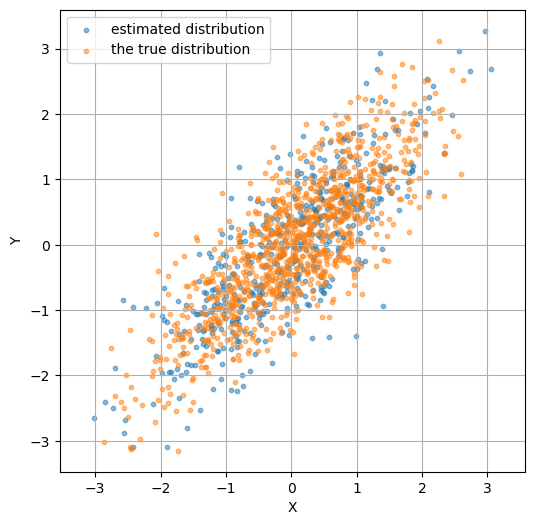

In [26]:
# Estimated Mean
mean_hat = [ 0.02332448,-0.00313353]


# Estimated Correlation matrix
cov_matrix_hat = np.array( [[1.01597497,0.83088271],[0.83088271,1.05782522]])


# Generate points
n = 500
data_new = np.random.multivariate_normal(mean_hat, cov_matrix_hat, n)
x_new, y_new = data_new[:, 0], data_new[:, 1]

# Plot (same clean style as before)
plt.figure(figsize=(6,6))
plt.scatter(x_new, y_new, alpha=0.5, s=10, label="estimated distribution")
plt.scatter(x, y, alpha=0.5, s=10, label="the true distribution")


plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# 🧩 Exercise :
> find the underlying distribution for this Bio-modal distribution of this cloud of points (we can see that a simple Gaussian could never fit those points)

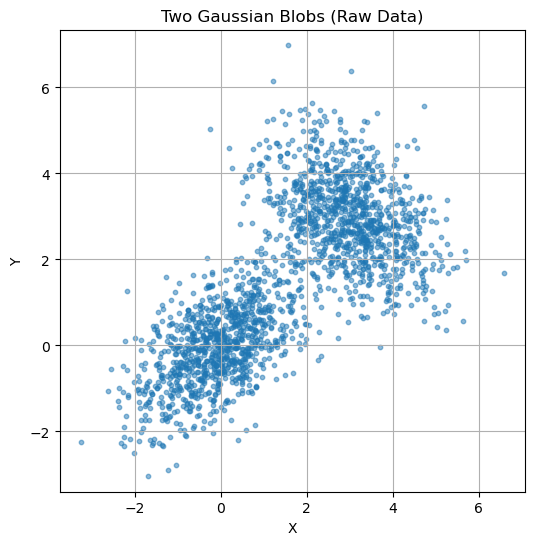

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ----------------------------
# 1. Generate two Gaussian blobs
# ----------------------------
np.random.seed(42)

n = 1000

# Blob 1
mean1 = [0, 0]
cov1 = [[1, 0.6],
        [0.6, 1]]
data1 = np.random.multivariate_normal(mean1, cov1, n)

# Blob 2
mean2 = [3, 3]
cov2 = [[1, -0.4],
        [-0.4, 1]]
data2 = np.random.multivariate_normal(mean2, cov2, n)

# Combine data
data = np.vstack([data1, data2])

# ----------------------------
# 2. Plot raw data
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.5)
plt.title("Two Gaussian Blobs (Raw Data)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()



In [23]:

# ----------------------------
# 3. Fit Gaussian Mixture Model
# ----------------------------
gmm = GaussianMixture(n_components=2, random_state=42)
print(gmm)
gmm.fit(data)


# ----------------------------
# 4. Function to draw ellipses
# ----------------------------
def draw_ellipse(position, covariance, ax, **kwargs):
    from matplotlib.patches import Ellipse
    import numpy.linalg as la

    # Eigen decomposition
    vals, vecs = la.eigh(covariance)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Compute angle
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height (2 std dev)
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(xy=position, width=width, height=height,
                      angle=theta, fill=False, **kwargs)
    ax.add_patch(ellipse)


# ----------------------------
# 5. Plot GMM approximation
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.3)

ax = plt.gca()

# Plot each Gaussian component
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, edgecolor='red', linewidth=2)

plt.title("GMM Approximation (2 Components)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()

GaussianMixture(n_components=2, random_state=42)


AttributeError: 'NoneType' object has no attribute 'split'